In [5]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt


def plot_ndcg_folder(
    folder_path,
    legend_outside=False,
    name_map=None,
    append_filename_to_legend=False
):

    if name_map is None:
        name_map = {}

    json_files = [
        f for f in os.listdir(folder_path)
        if f.endswith(".json")
    ]

    if len(json_files) == 0:
        raise ValueError("No JSON files found in folder")

    width = 12 if not legend_outside else 22

    plt.figure(figsize=(width, 8))

    plotted_lines = []

    for json_file in json_files:

        json_path = os.path.join(
            folder_path,
            json_file
        )

        with open(
            json_path,
            "r",
            encoding="utf-8"
        ) as f:

            data = json.load(f)

        embedding_model = data.get(
            "embedding_model",
            "unknown_model"
        )

        reranking_enabled = data.get(
            "reranking_enabled",
            False
        )

        reranking_model = data.get(
            "reranking_model",
            None
        )

        # ----------------------------------------
        # APPLY NAME MAP
        # ----------------------------------------

        embedding_model = name_map.get(
            embedding_model,
            embedding_model
        )

        if reranking_model is not None:

            reranking_model = name_map.get(
                reranking_model,
                reranking_model
            )

        avg_results = data["average_results"]

        ks = []
        ndcgs = []

        for key, value in avg_results.items():

            if value is None:
                continue

            ks.append(
                int(key.replace("ndcg@", ""))
            )

            ndcgs.append(value)

        sorted_pairs = sorted(
            zip(ks, ndcgs)
        )

        ks = [x[0] for x in sorted_pairs]
        ndcgs = [x[1] for x in sorted_pairs]

        mean_ndcg = float(
            np.mean(ndcgs)
        )

        # ----------------------------------------
        # BASE LABEL
        # ----------------------------------------

        if reranking_enabled and reranking_model:

            label = (
                f"{embedding_model} "
                f"+ {reranking_model}"
            )

        else:

            label = embedding_model

        # ----------------------------------------
        # OPTIONAL FILE NAME APPEND
        # ----------------------------------------

        if append_filename_to_legend:

            file_base = os.path.splitext(
                json_file
            )[0]

            distance_label = (
                file_base.replace("_", " ")
                + " distance"
            )

            label = (
                f"{label} "
                f"- {distance_label}"
            )

        line, = plt.plot(
            ks,
            ndcgs,
            marker="o",
            label=label
        )

        plotted_lines.append(
            (mean_ndcg, line, label)
        )

    plotted_lines.sort(
        key=lambda x: x[0],
        reverse=True
    )

    handles = [x[1] for x in plotted_lines]
    labels = [x[2] for x in plotted_lines]

    plt.xlabel("k")
    plt.ylabel("Average NDCG@k")

    plt.title(
        "Embedding / Reranker Comparison"
    )

    plt.grid(True)

    if legend_outside:

        plt.legend(
            handles,
            labels,
            bbox_to_anchor=(1.02, 1),
            loc="upper left"
        )

        plt.tight_layout(
            rect=[0, 0, 0.8, 1]
        )

    else:

        plt.legend(
            handles,
            labels
        )

        plt.tight_layout()

    plt.show()

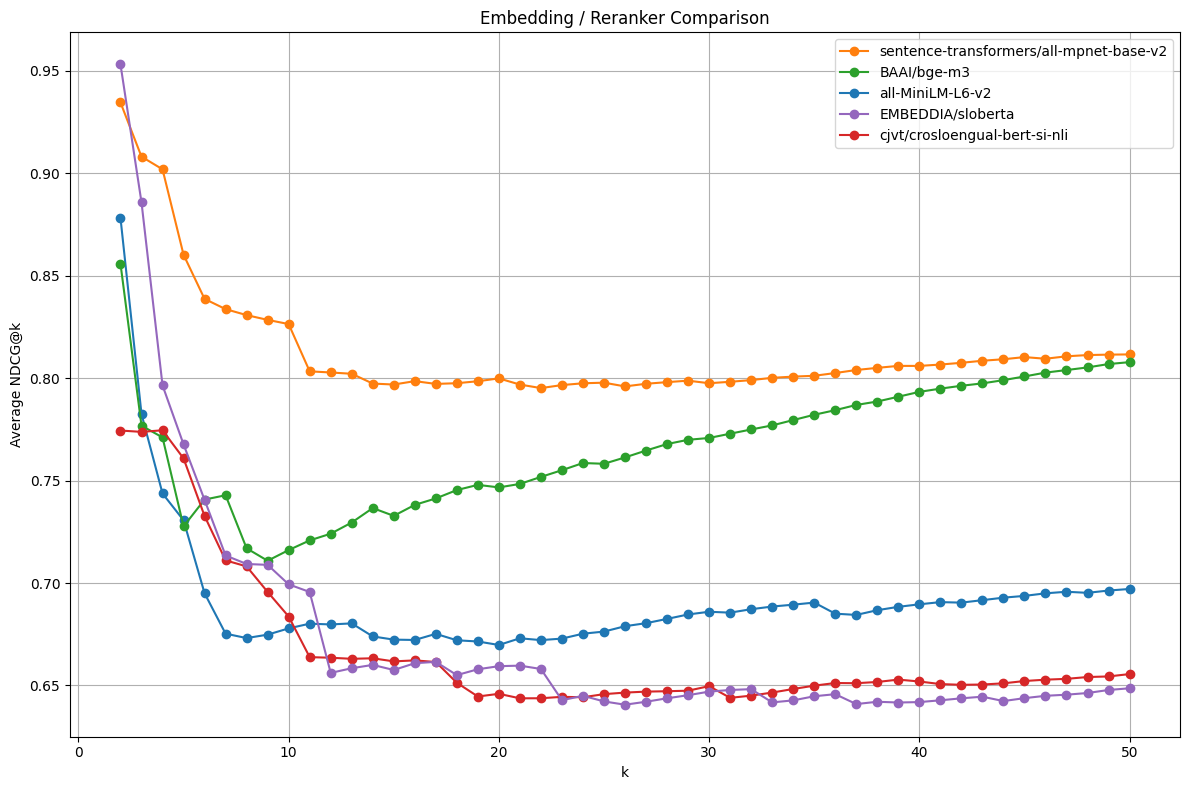

In [6]:
plot_ndcg_folder('./evaluated_models/no_rerankers')

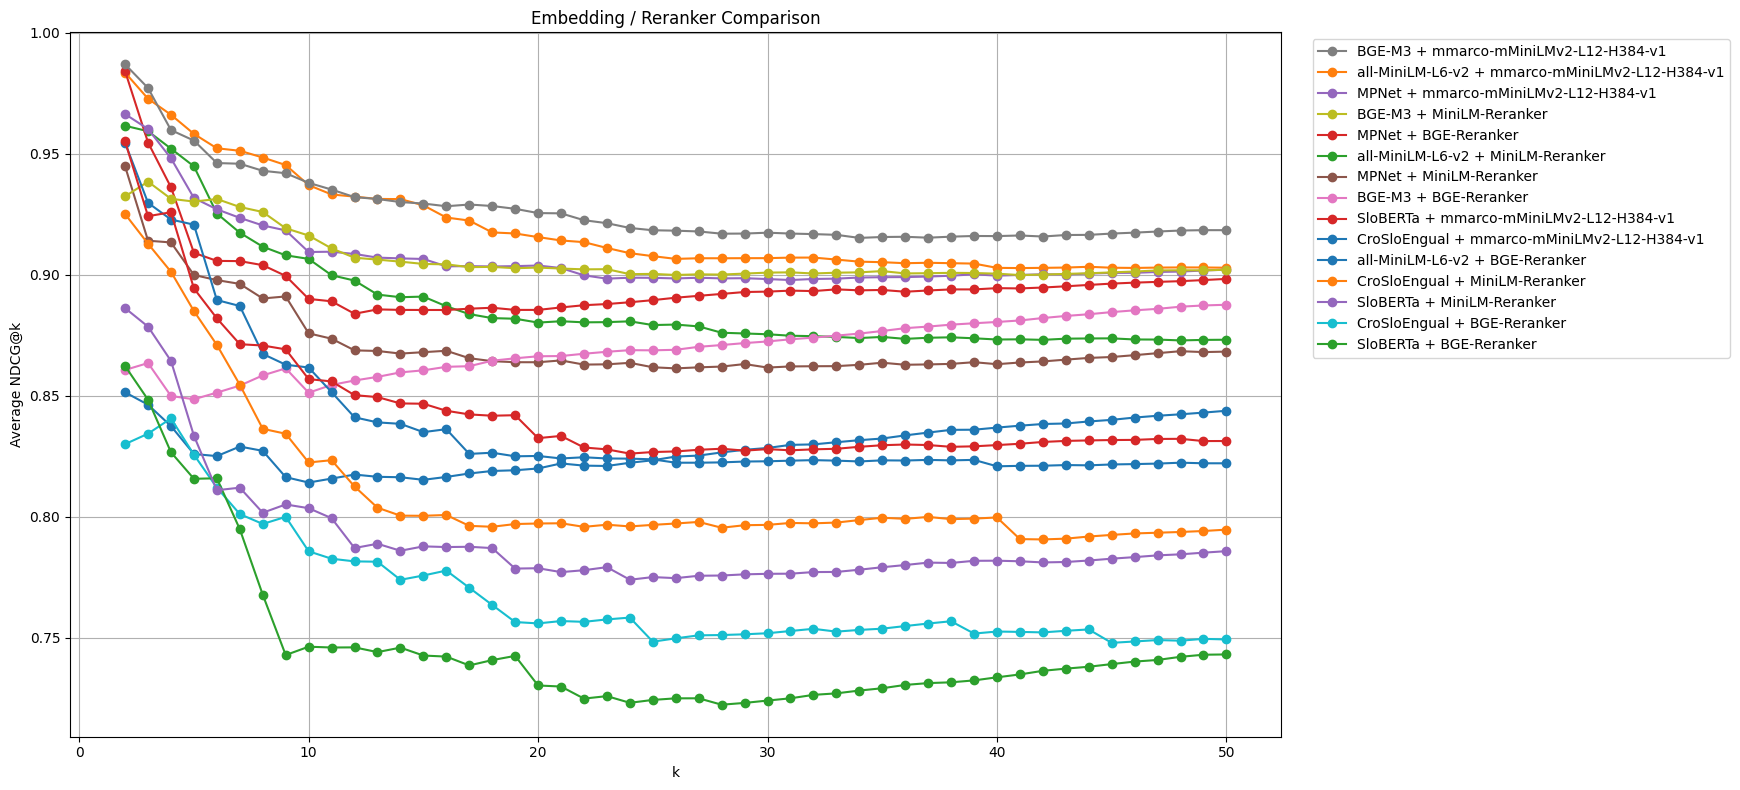

In [7]:
NAME_MAP = {
    "BAAI/bge-m3": "BGE-M3",
    "EMBEDDIA/sloberta": "SloBERTa",
    "sentence-transformers/all-mpnet-base-v2": "MPNet",
    "sentence-transformers/all-MiniLM-L6-v2": "MiniLM",
    "cross-encoder/ms-marco-MiniLM-L6-v2": "MiniLM-Reranker",
    "BAAI/bge-reranker-v2-m3": "BGE-Reranker",
    "cjvt/crosloengual-bert-si-nli" : 'CroSloEngual',
    "cross-encoder/mmarco-mMiniLMv2-L12-H384-v1" : "mmarco-mMiniLMv2-L12-H384-v1"
    
}

plot_ndcg_folder('./evaluated_models/rerankers', legend_outside=True, name_map=NAME_MAP)

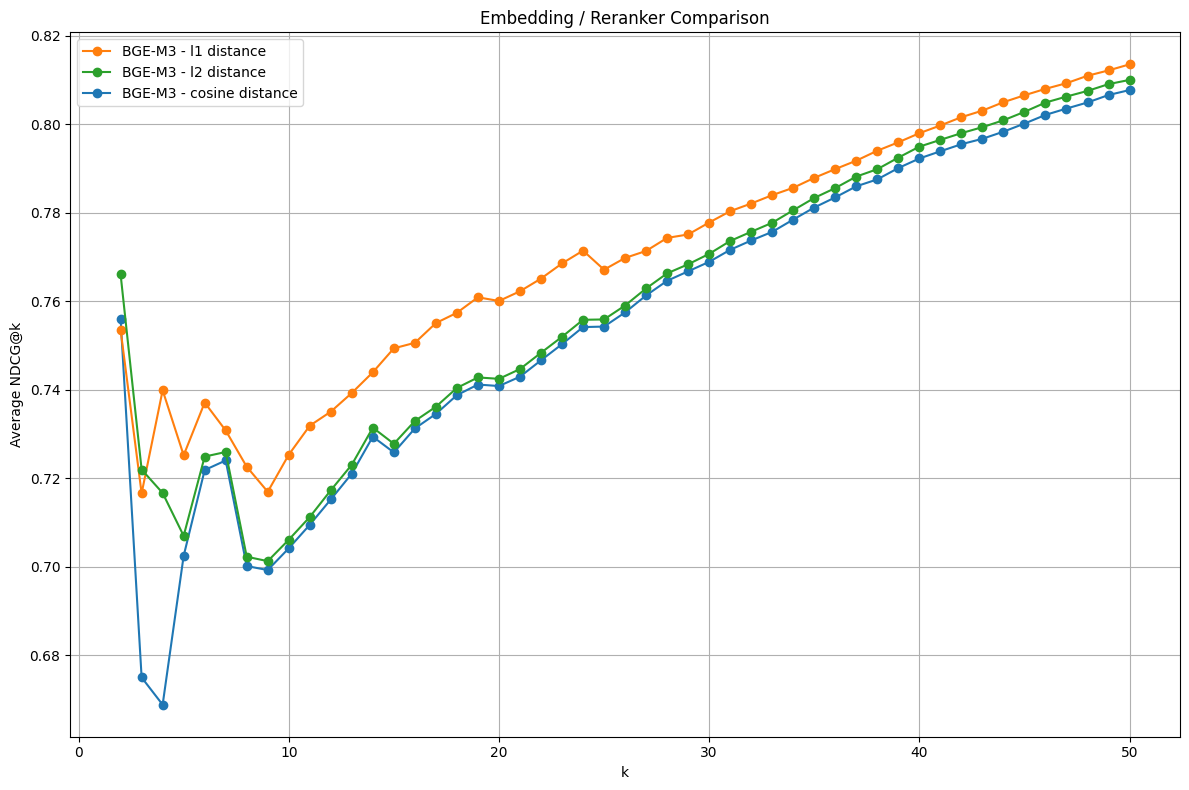

In [9]:
plot_ndcg_folder('./evaluated_models/metrics', legend_outside=False, name_map=NAME_MAP, append_filename_to_legend=True)